In [1]:
# 1. Thư viện xử lý dữ liệu (Cơ bản)
import pandas as pd
import numpy as np

# 2. Thư viện trực quan hóa (Cần thiết để trình bày biểu đồ)
import matplotlib.pyplot as plt
import seaborn as sns # Thêm cái này để biểu đồ đẹp và chuyên nghiệp hơn
%matplotlib inline 

# 3. Thư viện thuật toán (Thay vì import file, ta gọi trực tiếp thư viện)
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import sklearn.metrics as met
from sklearn.multiclass import OneVsOneClassifier

# 4. Tắt cảnh báo để Notebook trông sạch sẽ khi thuyết trình
import warnings
warnings.filterwarnings('ignore')

print("Thiết lập môi trường thành công!")

Thiết lập môi trường thành công!


# Taking input from user

In [2]:
# [Markdown] ## Bước: Xử lý lựa chọn từ người dùng
# Chúng ta cần ánh xạ từ tên thể loại (String) sang chỉ số cột (Index) trong ma trận đặc trưng.

def get_genre_index(genre_name, genre_mapping): 
    for index, name in genre_mapping.items(): 
         if genre_name == name: 
             return index 
    return None

# Dictionary này khớp với các cột sau khi One-hot Encoding (từ cột 2 đến 21)
genre_mapping = {
    2:"Action", 3:"Adventure", 4:"Animation", 5:"Biography", 6:"Comedy",
    7:"Crime", 8:"Drama", 9:"Family", 10:"Fantasy", 11:"History",
    12:"Horror", 13:"Music", 14:"Musical", 15:"Mystery", 16:"Romance",
    17:"Sci-Fi", 18:"Sport", 19:"Thriller", 20:"War", 21:"Western"
}

# Giả lập lựa chọn của người dùng (Trong Notebook nên gán cứng để dễ chạy mẫu)
user_choice = "Action" 

# Tìm chỉ số cột tương ứng
column_index = get_genre_index(user_choice, genre_mapping)

print(f"Người dùng chọn: {user_choice}")
print(f"Chỉ số cột tương ứng trong ma trận dữ liệu: {column_index}")

Người dùng chọn: Action
Chỉ số cột tương ứng trong ma trận dữ liệu: 2


In [3]:
dataset = pd.read_csv('IMDB-Movie-Data.csv')
print(dataset)

     Rank                    Title  ... Revenue (Millions) Metascore
0       1  Guardians of the Galaxy  ...             333.13      76.0
1       2               Prometheus  ...             126.46      65.0
2       3                    Split  ...             138.12      62.0
3       4                     Sing  ...             270.32      59.0
4       5            Suicide Squad  ...             325.02      40.0
..    ...                      ...  ...                ...       ...
995   996     Secret in Their Eyes  ...                NaN      45.0
996   997          Hostel: Part II  ...              17.54      46.0
997   998   Step Up 2: The Streets  ...              58.01      50.0
998   999             Search Party  ...                NaN      22.0
999  1000               Nine Lives  ...              19.64      11.0

[1000 rows x 12 columns]


# Sorting values according to rating in descending order

In [4]:
dataset = dataset.sort_values('Rating',ascending=False)
x= dataset.iloc[:,[2,8]]
print(x)

                        Genre  Rating
54         Action,Crime,Drama     9.0
80    Action,Adventure,Sci-Fi     8.8
117    Action,Biography,Drama     8.8
36     Adventure,Drama,Sci-Fi     8.6
96    Animation,Drama,Fantasy     8.6
..                        ...     ...
968    Action,Horror,Thriller     3.5
647   Fantasy,Horror,Thriller     3.2
871  Action,Adventure,Fantasy     2.7
42                     Horror     2.7
829                    Comedy     1.9

[1000 rows x 2 columns]


<Axes: >

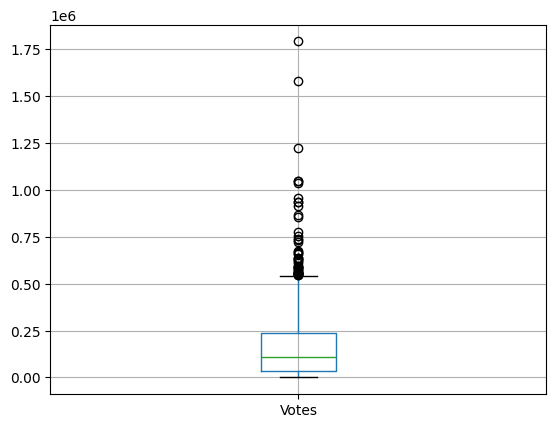

In [5]:
dataset.boxplot(column=['Votes'])

# Encoding Genre 

In [6]:
x = pd.concat([x.drop('Genre', axis=1), x['Genre'].str.get_dummies(sep=",")], axis=1)
print(x)

     Rating  Action  Adventure  Animation  ...  Sport  Thriller  War  Western
54      9.0       1          0          0  ...      0         0    0        0
80      8.8       1          1          0  ...      0         0    0        0
117     8.8       1          0          0  ...      0         0    0        0
36      8.6       0          1          0  ...      0         0    0        0
96      8.6       0          0          1  ...      0         0    0        0
..      ...     ...        ...        ...  ...    ...       ...  ...      ...
968     3.5       1          0          0  ...      0         1    0        0
647     3.2       0          0          0  ...      0         1    0        0
871     2.7       1          1          0  ...      0         0    0        0
42      2.7       0          0          0  ...      0         0    0        0
829     1.9       0          0          0  ...      0         0    0        0

[1000 rows x 21 columns]


In [7]:
X = x.iloc[:,0:21].values

In [8]:
from sklearn.decomposition import PCA
pca = PCA(n_components=None)#SInce we do not know how many eigen vectors are needed we keep value of n components=None so that we can get the eigen values of all the eigen vectors to figure out the best one
X = pca.fit_transform(X)
explained_variance = pca.explained_variance_ratio_
print(explained_variance)

[0.33238783 0.14317095 0.10089998 0.0705231  0.05540225 0.0459295
 0.03789689 0.03530911 0.03500896 0.02613341 0.02515884 0.02438035
 0.01652608 0.01301041 0.01021592 0.00877265 0.00573457 0.00520926
 0.00417902 0.00240437 0.00174652]


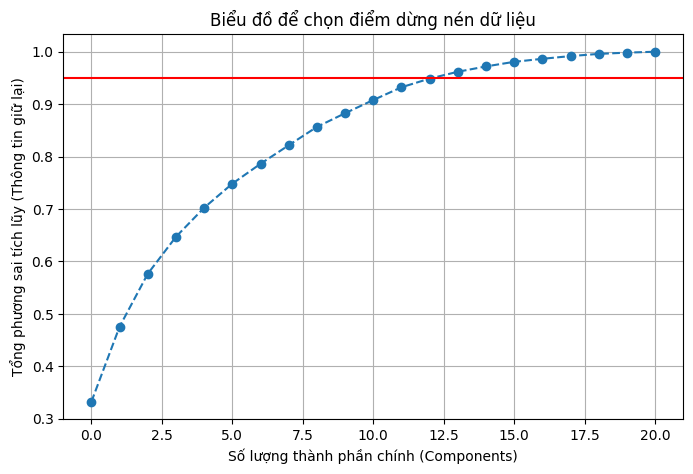

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Vẽ biểu đồ để quyết định chọn bao nhiêu n_components
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(explained_variance), marker='o', linestyle='--')
plt.xlabel('Số lượng thành phần chính (Components)')
plt.ylabel('Tổng phương sai tích lũy (Thông tin giữ lại)')
plt.title('Biểu đồ để chọn điểm dừng nén dữ liệu')
plt.axhline(y=0.95, color='r', linestyle='-') # Đường 95% để tham khảo
plt.grid()
plt.show()

In [10]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Nạp dữ liệu (Đảm bảo file nằm cùng thư mục)
dataset = pd.read_csv('IMDB-Movie-Data.csv')
df_clean = dataset[['Genre', 'Rating', 'Votes']].dropna()

# 2. TẠO X_encoded: Biến chữ thành số (One-Hot Encoding)
genres_columns = df_clean['Genre'].str.get_dummies(sep=",")
X_encoded = pd.concat([df_clean[['Rating', 'Votes']], genres_columns], axis=1)

# 3. TẠO X_scaled: Đưa mọi thứ về cùng một khung (Scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# 4. TẠO X_compressed: Nén giữ 95% thông tin (PCA)
pca_final = PCA(n_components=0.95)
X_compressed = pca_final.fit_transform(X_scaled)

print(f"✅ Thành công!")
print(f"1. Số cột ban đầu (X_encoded): {X_encoded.shape[1]}")
print(f"2. Số cột sau khi nén (X_compressed): {X_compressed.shape[1]}")
print(f"3. Lượng thông tin giữ lại: {pca_final.explained_variance_ratio_.sum()*100:.2f}%")

✅ Thành công!
1. Số cột ban đầu (X_encoded): 22
2. Số cột sau khi nén (X_compressed): 19
3. Lượng thông tin giữ lại: 95.68%


BẢNG CHỈ SỐ ĐÓNG GÓP CỦA CÁC CỘT GỐC VÀO 19 PC:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19
Rating,-0.010,-0.244,0.506,-0.244,-0.233,-0.086,-0.164,0.099,-0.033,-0.053,0.017,0.013,-0.170,0.099,-0.081,-0.028,-0.000,0.093,-0.143
Votes,0.290,-0.079,0.430,-0.256,-0.091,-0.159,-0.052,0.070,0.006,0.026,0.004,0.008,-0.282,0.133,-0.274,0.137,-0.048,0.095,0.037
Action,0.406,0.157,0.136,0.080,0.255,0.120,0.325,-0.105,-0.003,0.063,-0.080,0.100,-0.019,-0.074,0.083,0.132,0.093,0.369,-0.204
Adventure,0.493,-0.146,0.063,0.126,0.020,0.035,-0.008,-0.022,0.028,-0.001,0.042,-0.068,0.063,-0.085,0.294,-0.129,0.090,0.026,-0.231
Animation,0.185,-0.296,-0.074,-0.087,-0.270,0.368,-0.380,-0.012,-0.061,-0.095,-0.083,0.063,-0.024,-0.103,0.406,-0.211,-0.143,0.082,0.352
Biography,-0.213,-0.126,0.313,0.381,0.161,0.196,-0.142,0.087,0.014,0.038,0.056,-0.055,-0.057,-0.071,-0.138,-0.063,0.678,-0.019,0.271
Comedy,-0.025,-0.400,-0.333,-0.267,0.062,0.243,-0.023,-0.058,-0.025,0.053,-0.076,0.088,-0.139,-0.080,-0.388,0.235,0.038,-0.303,-0.204
Crime,-0.123,0.202,0.154,-0.153,-0.266,0.412,0.519,-0.028,-0.011,0.142,-0.096,-0.012,-0.025,-0.102,-0.180,-0.131,-0.171,0.122,0.384
Drama,-0.440,-0.100,0.260,0.035,-0.010,-0.178,0.136,0.017,-0.025,0.018,0.010,-0.075,0.066,0.011,0.203,-0.422,-0.219,-0.096,-0.332
Family,0.122,-0.213,-0.138,0.256,-0.392,-0.078,0.022,0.134,-0.033,0.035,0.105,-0.131,0.558,0.346,-0.338,0.010,-0.011,0.273,-0.001


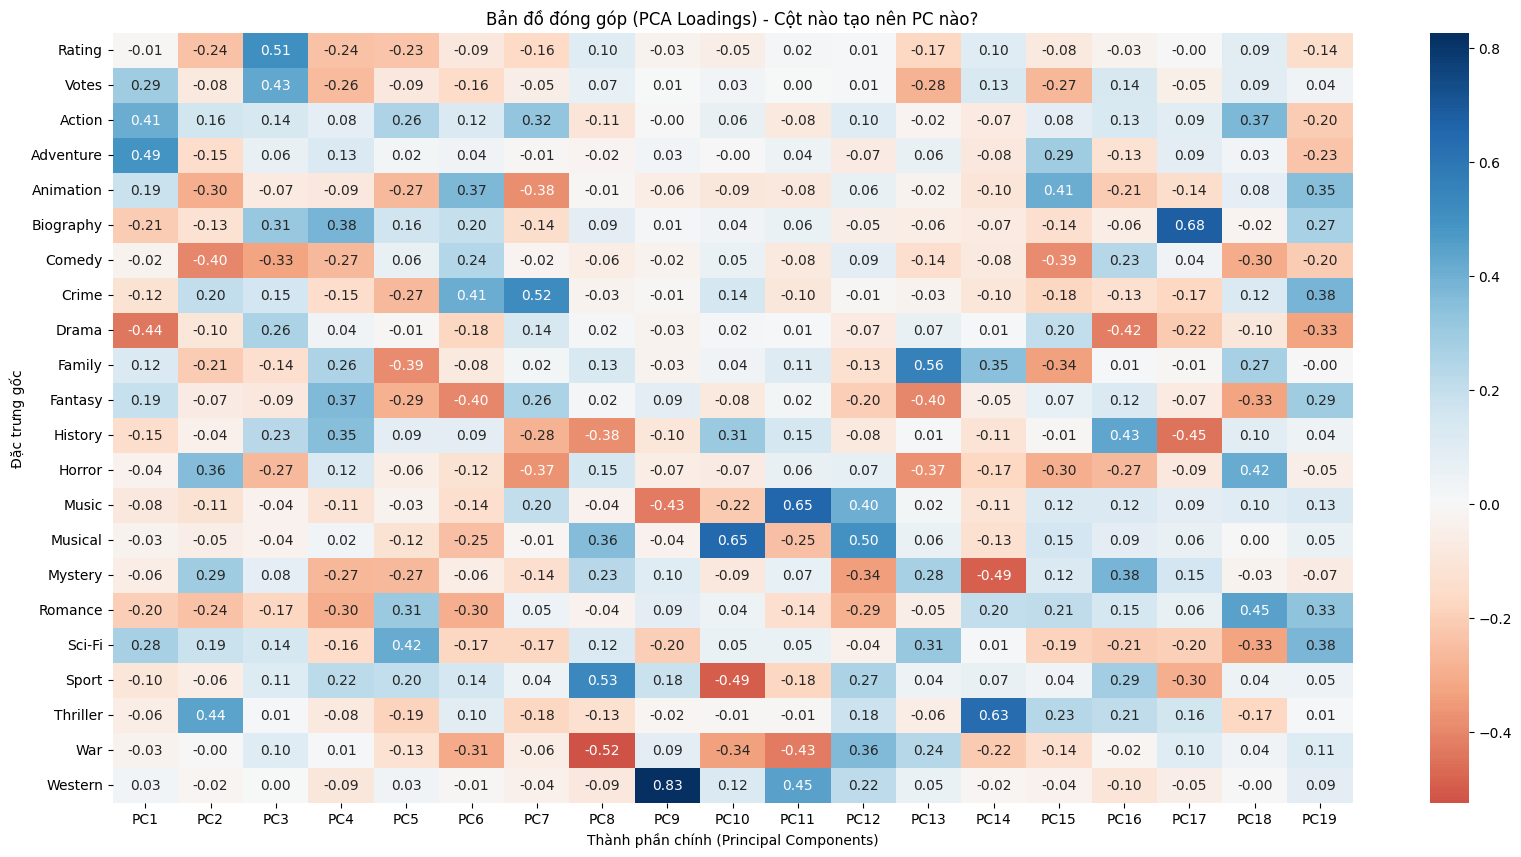

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Lấy ma trận Weights (Loadings) của toàn bộ 19 PC
# pca_final.components_ có hình dạng (n_components, n_features)
# Ta cần chuyển vị (.T) để dòng là tên cột gốc, cột là các PC
loadings_full = pd.DataFrame(
    pca_final.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca_final.n_components_)], 
    index=X_encoded.columns
)

# 2. Hiển thị bảng số liệu (19 cột PC)
print("BẢNG CHỈ SỐ ĐÓNG GÓP CỦA CÁC CỘT GỐC VÀO 19 PC:")
display(loadings_full.round(3))

# 3. Vẽ Heatmap để nhìn trực quan "màu sắc" đóng góp
plt.figure(figsize=(20, 10))
sns.heatmap(loadings_full, annot=True, cmap='RdBu', center=0, fmt=".2f")
plt.title("Bản đồ đóng góp (PCA Loadings) - Cột nào tạo nên PC nào?")
plt.ylabel("Đặc trưng gốc")
plt.xlabel("Thành phần chính (Principal Components)")
plt.show()

In [12]:
np.set_printoptions(precision=2)
print(X)

[[ 2.29e+00 -2.63e-01 -5.17e-01 ... -4.49e-02 -2.25e-03 -1.07e-02]
 [ 1.87e+00 -1.59e+00 -1.47e-01 ... -2.09e-02 -1.38e-02 -1.34e-03]
 [ 2.15e+00 -2.38e-01 -3.57e-01 ... -3.96e-02 -1.30e-03 -6.62e-03]
 ...
 [-4.06e+00 -5.71e-01 -1.62e-01 ...  2.73e-02 -2.60e-04  8.54e-03]
 [-4.06e+00  6.30e-01 -1.74e-01 ... -2.81e-02 -2.25e-02 -9.17e-03]
 [-4.77e+00  7.58e-01  6.74e-01 ... -2.09e-02 -2.54e-02 -3.07e-03]]


In [13]:
y= dataset.iloc[:,0].values
print(y)

[   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   60   61   62   63   64   65   66   67   68   69   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   85   86   87   88   89   90   91   92   93   94   95   96   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  118  119  120  121  122  123  124  125  126
  127  128  129  130  131  132  133  134  135  136  137  138  139  140
  141  142  143  144  145  146  147  148  149  150  151  152  153  154
  155  156  157  158  159  160  161  162  163  164  165  166  167  168
  169  170  171  172  173  174  175  176  177  178  179  180  181  182
  183  184  185  186  187  188  189  190  191  192  193  194  195  196
  197 

In [14]:
from sklearn import svm
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.multiclass import OneVsOneClassifier # Thêm thư viện này
from sklearn.multiclass import OneVsRestClassifier # Thêm thư viện này
import pandas as pd
import numpy as np

# --- BƯỚC 1: CHIA NHÓM RANK ---
dataset['Rank_Group'] = pd.cut(dataset['Rank'], bins=[0, 200, 400, 600, 800, 1000], labels=[0, 1, 2, 3, 4])

# --- BƯỚC 2: CHUẨN BỊ DỮ LIỆU ---
X_final = X[:, :2] 
y_final = dataset['Rank_Group']
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# --- BƯỚC 3: HUẤN LUYỆN MULTI-CLASS SVM (Tường minh OvO) ---
# Khởi tạo model gốc
base_model = svm.SVC(kernel='rbf', C=1.0, gamma='scale')

# Bọc vào bộ phân loại One-vs-One 
clf = OneVsRestClassifier(base_model)
clf.fit(X_train, y_train)

# --- BƯỚC 4: HIỂN THỊ CƠ CHẾ "CHIA ĐỂ TRỊ" ---
print(f"--- THÔNG TIN CƠ CHẾ ONE-VS-ONE ---")
num_classes = len(clf.classes_)
num_estimators = len(clf.estimators_)
print(f"Số lượng nhóm thực tế: {num_classes}")
print(f"Số lượng bộ phân loại nhị phân được tạo (N*(N-1)/2): {num_estimators}")

# Liệt kê các cặp đấu để làm rõ logic trong báo cáo
classes = clf.classes_
count = 0
print("\nDanh sách các cặp phân loại nhị phân:")
for i in range(len(classes)):
    for j in range(i + 1, len(classes)):
        count += 1
        print(f"  Bộ {count}: Nhóm {classes[i]} đối đầu Nhóm {classes[j]}")

# --- BƯỚC 5: ĐÁNH GIÁ ĐỘ CHÍNH XÁC ---
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))

print(f"\n--- KẾT QUẢ ĐÁNH GIÁ ---")
print(f"1. Độ chính xác tập Train: {train_acc*100:.2f}%")
print(f"2. Độ chính xác tập Test: {test_acc*100:.2f}%")

target_names = ['Top 1-200', '201-400', '401-600', '601-800', '801-1000']
print("\nBÁO CÁO PHÂN LOẠI CHI TIẾT:")
print(classification_report(y_test, clf.predict(X_test), target_names=target_names))

--- THÔNG TIN CƠ CHẾ ONE-VS-ONE ---
Số lượng nhóm thực tế: 5
Số lượng bộ phân loại nhị phân được tạo (N*(N-1)/2): 5

Danh sách các cặp phân loại nhị phân:
  Bộ 1: Nhóm 0 đối đầu Nhóm 1
  Bộ 2: Nhóm 0 đối đầu Nhóm 2
  Bộ 3: Nhóm 0 đối đầu Nhóm 3
  Bộ 4: Nhóm 0 đối đầu Nhóm 4
  Bộ 5: Nhóm 1 đối đầu Nhóm 2
  Bộ 6: Nhóm 1 đối đầu Nhóm 3
  Bộ 7: Nhóm 1 đối đầu Nhóm 4
  Bộ 8: Nhóm 2 đối đầu Nhóm 3
  Bộ 9: Nhóm 2 đối đầu Nhóm 4
  Bộ 10: Nhóm 3 đối đầu Nhóm 4

--- KẾT QUẢ ĐÁNH GIÁ ---
1. Độ chính xác tập Train: 90.75%
2. Độ chính xác tập Test: 88.50%

BÁO CÁO PHÂN LOẠI CHI TIẾT:
              precision    recall  f1-score   support

   Top 1-200       0.97      0.91      0.94        33
     201-400       0.88      0.94      0.91        48
     401-600       0.80      0.89      0.85        37
     601-800       0.80      0.84      0.82        38
    801-1000       1.00      0.84      0.91        44

    accuracy                           0.89       200
   macro avg       0.89      0.88      0.8

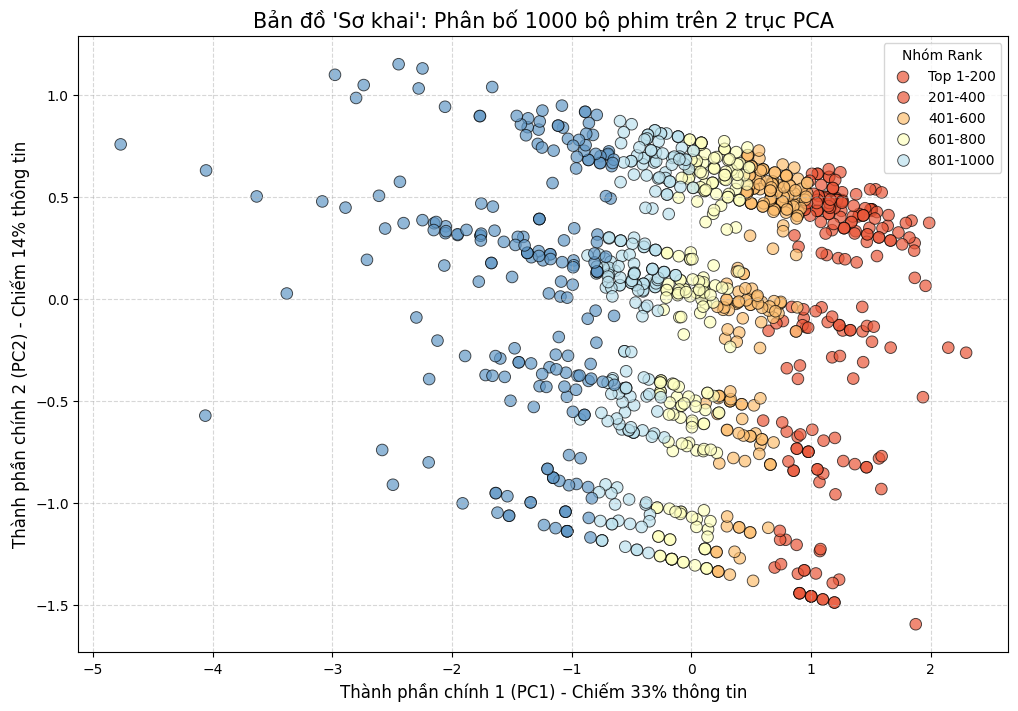

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập kích thước hình vẽ
plt.figure(figsize=(12, 8))

# Sử dụng Seaborn để vẽ các điểm dữ liệu
# X_final[:, 0] là trục hoành (PC1)
# X_final[:, 1] là trục tung (PC2)
# hue=y_final dùng để tô màu theo 5 nhóm Rank
scatter = sns.scatterplot(
    x=X_final[:, 0], 
    y=X_final[:, 1], 
    hue=y_final, 
    palette='RdYlBu', 
    s=70, 
    alpha=0.7, 
    edgecolor='k'
)

# Thêm tiêu đề và chú thích
plt.title("Bản đồ 'Sơ khai': Phân bố 1000 bộ phim trên 2 trục PCA", fontsize=15)
plt.xlabel("Thành phần chính 1 (PC1) - Chiếm 33% thông tin", fontsize=12)
plt.ylabel("Thành phần chính 2 (PC2) - Chiếm 14% thông tin", fontsize=12)

# Chỉnh sửa Legend (Chú thích) cho dễ hiểu
plt.legend(title="Nhóm Rank", labels=['Top 1-200', '201-400', '401-600', '601-800', '801-1000'])

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

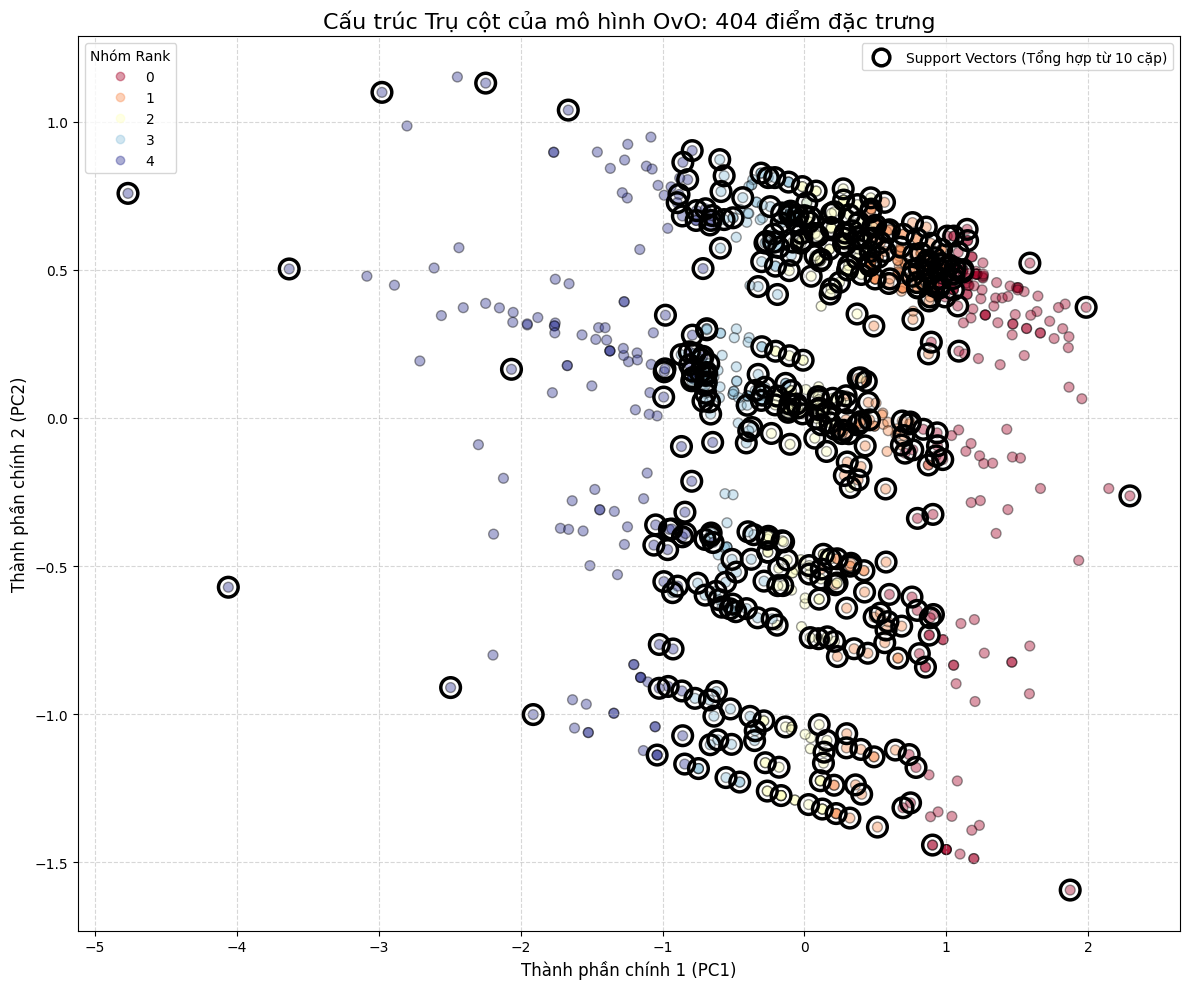

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 1. TRUY CẬP SUPPORT VECTORS TỪ CÁC BỘ PHÂN LOẠI CON (OvO)
# clf.estimators_ chứa 10 bộ SVC nhị phân. Ta lặp qua từng bộ để lấy SV.
all_sv = []
for est in clf.estimators_:
    all_sv.append(est.support_vectors_)

# Gộp tất cả SV từ 10 cặp đấu lại thành một mảng duy nhất
# Sử dụng np.vstack để chồng các mảng lên nhau
support_vectors_raw = np.vstack(all_sv)

# (Quan trọng) Loại bỏ các điểm trùng lặp. 
# Vì một điểm dữ liệu có thể là Support Vector của nhiều cặp đấu cùng lúc.
support_vectors = np.unique(support_vectors_raw, axis=0)

# 2. THIẾT LẬP KÍCH THƯỚC HÌNH VẼ
plt.figure(figsize=(12, 10))

# 3. LỚP NỀN: Vẽ TOÀN BỘ dữ liệu Train
# Đảm bảo X_train và y_train ở định dạng numpy để matplotlib xử lý mượt mà
X_train_np = X_train.numpy() if hasattr(X_train, 'numpy') else X_train
y_train_np = y_train.numpy() if hasattr(y_train, 'numpy') else np.array(y_train)

scatter_bg = plt.scatter(
    X_train_np[:, 0], 
    X_train_np[:, 1], 
    c=y_train_np, 
    cmap='RdYlBu', 
    s=50, 
    alpha=0.4, 
    edgecolor='k', 
    label='Dữ liệu Train (Nền)'
)

# 4. LỚP TRỤ CỘT: Vẽ các Support Vectors đã gộp
scatter_sv = plt.scatter(
    support_vectors[:, 0], 
    support_vectors[:, 1], 
    s=200, 
    facecolors='none', 
    edgecolors='black', 
    linewidths=2.5, 
    zorder=10 # Đảm bảo vòng tròn nằm trên cùng
)

# 5. THÊM CHÚ THÍCH VÀ CHI TIẾT
plt.title(f"Cấu trúc Trụ cột của mô hình OvO: {len(support_vectors)} điểm đặc trưng", fontsize=16)
plt.xlabel("Thành phần chính 1 (PC1)", fontsize=12)
plt.ylabel("Thành phần chính 2 (PC2)", fontsize=12)

# Legend cho các nhóm Rank
legend1 = plt.legend(*scatter_bg.legend_elements(), title="Nhóm Rank", loc="upper left")
plt.gca().add_artist(legend1)

# Legend cho Support Vectors
from matplotlib.lines import Line2D
legend_elements_sv = [
    Line2D([0], [0], marker='o', color='w', label='Support Vectors (Tổng hợp từ 10 cặp)',
           markeredgecolor='black', markeredgewidth=2.5, markersize=12, markerfacecolor='none')
]
plt.legend(handles=legend_elements_sv, loc="upper right")

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

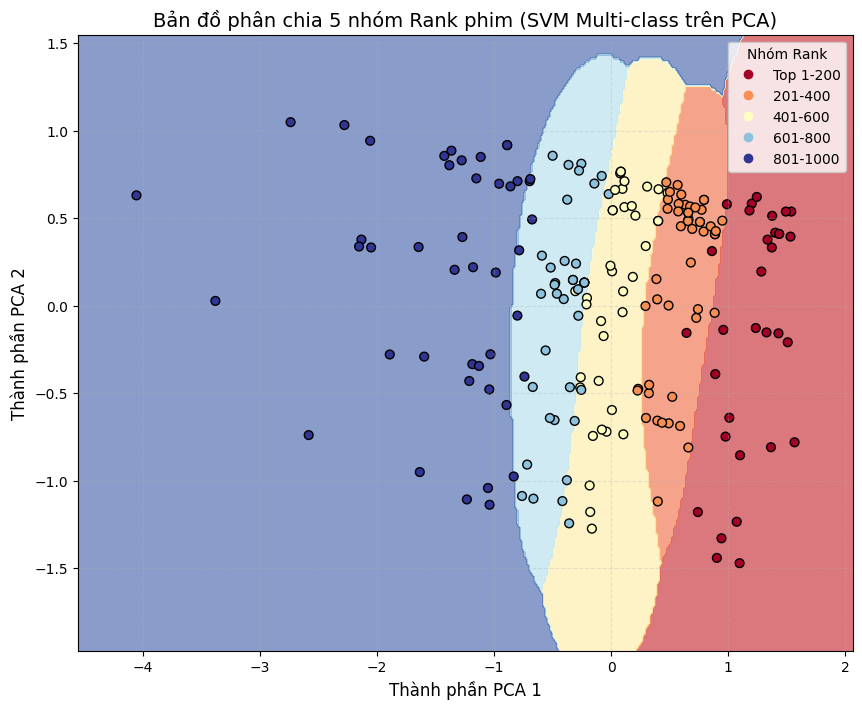

In [17]:
import matplotlib.pyplot as plt

def plot_svm_boundaries(clf, X, y, target_names):
    # 1. Tạo lưới tọa độ (Meshgrid)
    h = .02  # Bước nhảy của lưới (càng nhỏ hình càng mịn)
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # 2. Dự đoán vùng màu cho từng ô trên lưới
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 3. Vẽ biểu đồ
    plt.figure(figsize=(10, 8))
    # Tô màu các vùng quyết định (Decision Regions)
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.6)
    
    # Vẽ các điểm phim thực tế (Tập Test)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k', s=40)
    
    plt.title("Bản đồ phân chia 5 nhóm Rank phim (SVM Multi-class trên PCA)", fontsize=14)
    plt.xlabel("Thành phần PCA 1", fontsize=12)
    plt.ylabel("Thành phần PCA 2", fontsize=12)
    plt.legend(handles=scatter.legend_elements()[0], labels=target_names, title="Nhóm Rank")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

# Gọi hàm vẽ
plot_svm_boundaries(clf, X_test, y_test, target_names=['Top 1-200', '201-400', '401-600', '601-800', '801-1000'])

<Figure size 900x700 with 0 Axes>

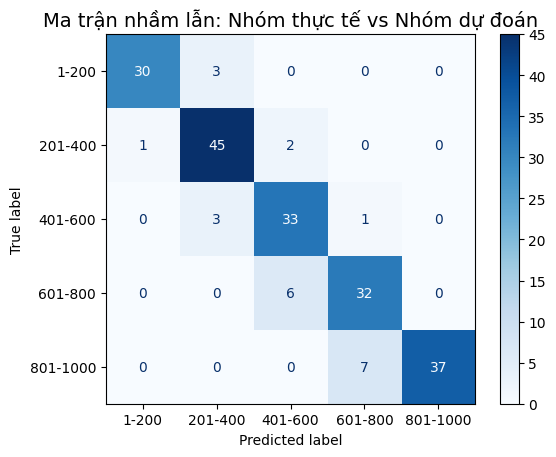

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(9, 7))
# Vẽ ma trận nhầm lẫn từ mô hình đã huấn luyện
cmd = ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, 
    display_labels=['1-200', '201-400', '401-600', '601-800', '801-1000'],
    cmap=plt.cm.Blues,
    values_format='d' # Hiển thị số lượng phim cụ thể
)
plt.title("Ma trận nhầm lẫn: Nhóm thực tế vs Nhóm dự đoán", fontsize=14)
plt.grid(False) # Tắt grid để nhìn rõ các ô màu
plt.show()

In [19]:
# Dự đoán nhãn cho tập Test
y_pred = clf.predict(X_test)

# Tìm chỉ số của những phim bị đoán sai (y_test khác y_pred)
# Lưu ý: Do train_test_split có random_state=42, ta cần lấy đúng index của test set
test_indices = y_test.index
misclassified_mask = y_test.values != y_pred
misclassified_indices = test_indices[misclassified_mask]

# Trích xuất 10 phim bị đoán sai tiêu biểu từ dataset gốc
misclassified_movies = dataset.loc[misclassified_indices].copy()
misclassified_movies['Predicted_Group'] = y_pred[misclassified_mask]

print(f"--- DANH SÁCH CÁC PHIM BỊ ĐOÁN SAI (8% SAI SỐ) ---")
# Hiển thị Rank thực tế, Thể loại và Rating để so sánh
print(misclassified_movies[['Rank', 'Title', 'Genre', 'Rating', 'Predicted_Group']].head(10))

--- DANH SÁCH CÁC PHIM BỊ ĐOÁN SAI (8% SAI SỐ) ---
     Rank                  Title  ... Rating  Predicted_Group
626   627  X-Men: The Last Stand  ...    6.7                2
811   812                   Mama  ...    6.2                3
371   372        The Maze Runner  ...    6.8                2
210   211            San Andreas  ...    6.1                0
198   199     The Imitation Game  ...    8.1                1
601   602           Blood Father  ...    6.4                2
439   440  Folk Hero & Funny Guy  ...    5.6                1
617   618    Free State of Jones  ...    6.9                2
820   821        Suite Française  ...    6.9                3
604   605  The Rise of the Krays  ...    5.1                2

[10 rows x 5 columns]


In [20]:
# 1. Chọn ngẫu nhiên 10 chỉ số từ tập Test
import random
random.seed(42) # Giữ kết quả cố định để dễ theo dõi
sample_indices = random.sample(range(len(y_test)), 10)

# 2. Lấy dữ liệu đặc trưng và nhãn thực tế của 10 phim này
X_sample = X_test[sample_indices]
y_actual = y_test.iloc[sample_indices].values

# 3. Yêu cầu mô hình dự đoán (Sử dụng cơ chế OvO đã học)
y_pred_sample = clf.predict(X_sample)

# 4. Lấy thông tin chi tiết từ dataset gốc để hiển thị
# Chúng ta dùng index gốc của y_test để truy vấn ngược lại tên phim
original_test_indices = y_test.index[sample_indices]
sample_info = dataset.loc[original_test_indices, ['Title', 'Rank', 'Rating']].copy()

# 5. Thêm cột Nhãn thực tế và Nhãn dự đoán vào bảng
group_map = {0: 'Top 1-200', 1: '201-400', 2: '401-600', 3: '601-800', 4: '801-1000'}
sample_info['Thực tế'] = [group_map[i] for i in y_actual]
sample_info['Máy đoán'] = [group_map[i] for i in y_pred_sample]

# 6. Đánh giá đúng/sai
sample_info['Kết quả'] = np.where(sample_info['Thực tế'] == sample_info['Máy đoán'], "✅ Đúng", "❌ Sai")

print("--- THỬ NGHIỆM DỰ ĐOÁN TRÊN 10 BỘ PHIM NGẪU NHIÊN ---")
print(sample_info[['Title', 'Rank', 'Thực tế', 'Máy đoán', 'Kết quả']])

--- THỬ NGHIỆM DỰ ĐOÁN TRÊN 10 BỘ PHIM NGẪU NHIÊN ---
                                              Title  Rank  ...   Máy đoán Kết quả
650  Sweeney Todd: The Demon Barber of Fleet Street   651  ...    601-800  ✅ Đúng
902                                         What If   903  ...   801-1000  ✅ Đúng
626                           X-Men: The Last Stand   627  ...    401-600   ❌ Sai
749                  Percy Jackson: Sea of Monsters   750  ...    601-800  ✅ Đúng
107                            The Legend of Tarzan   108  ...  Top 1-200  ✅ Đúng
542                                        Spectral   543  ...    401-600  ✅ Đúng
10          Fantastic Beasts and Where to Find Them    11  ...  Top 1-200  ✅ Đúng
198                              The Imitation Game   199  ...    201-400   ❌ Sai
942                                      Transpecos   943  ...   801-1000  ✅ Đúng
101                                            Thor   102  ...  Top 1-200  ✅ Đúng

[10 rows x 5 columns]
